## Import Libraries:

In [61]:
!pip install xgboost -q


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Importing inbuilt dataset "Diamonds" from seaborn:

In [63]:
df = sns.load_dataset("diamonds")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Plot data as scatterplot:

<Axes: xlabel='carat', ylabel='cut'>

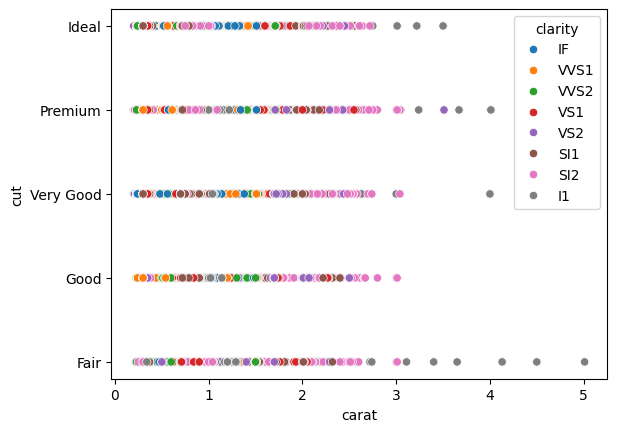

In [64]:
sns.scatterplot(x="carat",y="cut",hue="clarity",data=df)

## Split data into X and y:

In [65]:
X = df.drop("cut",axis=1)
y = df["cut"]

## Encoding:

In [66]:
le = LabelEncoder()
X["color"] = le.fit_transform(df["color"])
X["clarity"] = le.fit_transform(df["clarity"])

y = le.fit_transform(y)

## Training Testing and Spliting:

In [67]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)

## Decision Tree Classifier:

In [68]:
%%time 
dt = DecisionTreeClassifier() 
dt.fit(X_train,y_train) 
dt_pred = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 0.7838338895068595
Precision: 0.7772646863306312
Recall   : 0.7838338895068595
F1 Score : 0.7773479605200477
CPU times: total: 422 ms
Wall time: 504 ms


## Random Forest :

In [69]:
%%time 
rf = RandomForestClassifier() 
rf.fit(X_train,y_train) 
rf_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 0.7838338895068595
Precision: 0.7772646863306312
Recall   : 0.7838338895068595
F1 Score : 0.7773479605200477
CPU times: total: 9.3 s
Wall time: 11.6 s


## XGboost:

In [70]:
%%time
xgb = XGBClassifier()
xgb.fit(X_train,y_train) 
xgb_pred = xgb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 0.7838338895068595
Precision: 0.7772646863306312
Recall   : 0.7838338895068595
F1 Score : 0.7773479605200477
CPU times: total: 4.47 s
Wall time: 1.33 s


## Make a Bar plot showing each of the matrix with respect to the model:

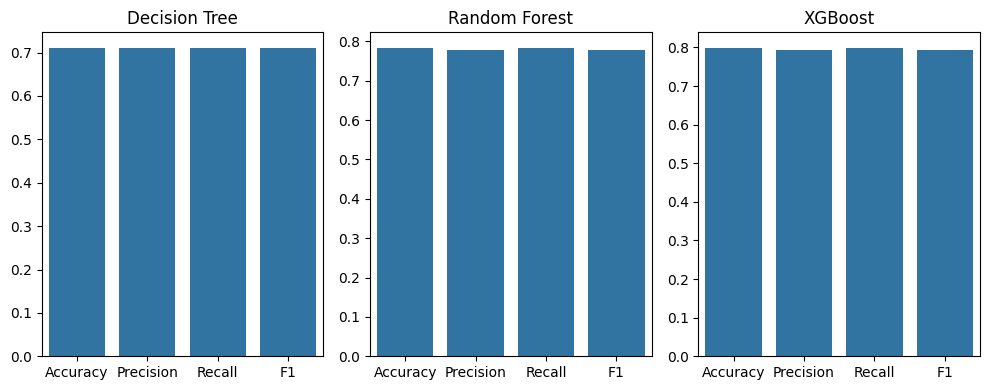

In [72]:
plt.figure(figsize=(10,4))

# Decision Tree
plt.subplot(1,3,1)
sns.barplot(
    x=["Accuracy","Precision","Recall","F1"],
    y=[
        accuracy_score(y_test, dt_pred),
        precision_score(y_test, dt_pred, average="weighted"),
        recall_score(y_test, dt_pred, average="weighted"),
        f1_score(y_test, dt_pred, average="weighted")
    ]
)
plt.title("Decision Tree")

# Random Forest
plt.subplot(1,3,2)
sns.barplot(
    x=["Accuracy","Precision","Recall","F1"],
    y=[
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted")
    ]
)
plt.title("Random Forest")

# XGBoost
plt.subplot(1,3,3)
sns.barplot(
    x=["Accuracy","Precision","Recall","F1"],
    y=[
        accuracy_score(y_test, xgb_pred),
        precision_score(y_test, xgb_pred, average="weighted"),
        recall_score(y_test, xgb_pred, average="weighted"),
        f1_score(y_test, xgb_pred, average="weighted")
    ]
)
plt.title("XGBoost")

plt.tight_layout()
plt.show()